In [1]:
import sys
print(sys.executable)

/opt/miniconda3/envs/215a/bin/python


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
USArrests = pd.read_csv("../data/USArrests.csv")
stateCoord = pd.read_csv("../data/stateCoord.csv")

In [4]:
USArrests.head()

,State,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [5]:
stateCoord.head()

,State,lon,lat
0,Alabama,-86.592392,34.735676
1,Alaska,-168.187471,53.330810
2,Arizona,-111.615136,36.246377
3,Arkansas,-92.240455,36.374502
4,California,-120.386476,34.034180


In [6]:
USArrests.columns

Index(['State', 'Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='str')

In [7]:
stateCoord.columns

Index(['State         ', 'lon              ', 'lat'], dtype='str')

In [8]:
arrests = pd.merge(USArrests, stateCoord, on="State")

KeyError: 'State'

In [9]:
stateCoord.columns = stateCoord.columns.str.strip()

In [10]:
stateCoord.columns

Index(['State', 'lon', 'lat'], dtype='str')

In [11]:
arrests = pd.merge(USArrests, stateCoord, on="State")

In [12]:
arrests.head()

,State,Murder,Assault,UrbanPop,Rape,lon,lat


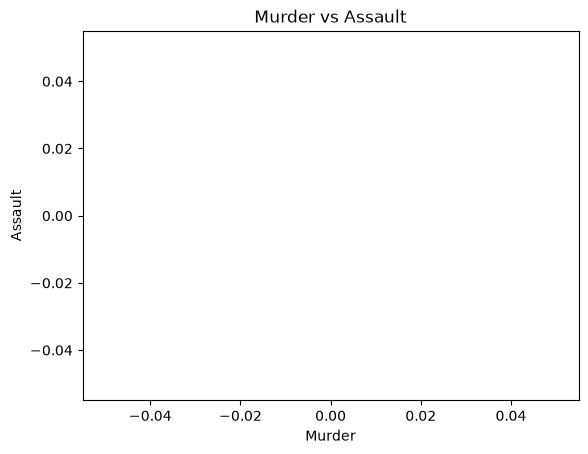

In [13]:
plt.scatter(arrests["Murder"], arrests["Assault"])
plt.xlabel("Murder")
plt.ylabel("Assault")
plt.title("Murder vs Assault")
plt.show()

In [14]:
USArrests["State"] = USArrests["State"].str.strip()
stateCoord["State"] = stateCoord["State"].str.strip()

In [15]:
arrests = pd.merge(USArrests, stateCoord, on="State")

In [16]:
arrests.head()

,State,Murder,Assault,UrbanPop,Rape,lon,lat
0,Alabama,13.2,236,58,21.2,-86.592392,34.735676
1,Alaska,10.0,263,48,44.5,-168.187471,53.330810
2,Arizona,8.1,294,80,31.0,-111.615136,36.246377
3,Arkansas,8.8,190,50,19.5,-92.240455,36.374502
4,California,9.0,276,91,40.6,-120.386476,34.034180


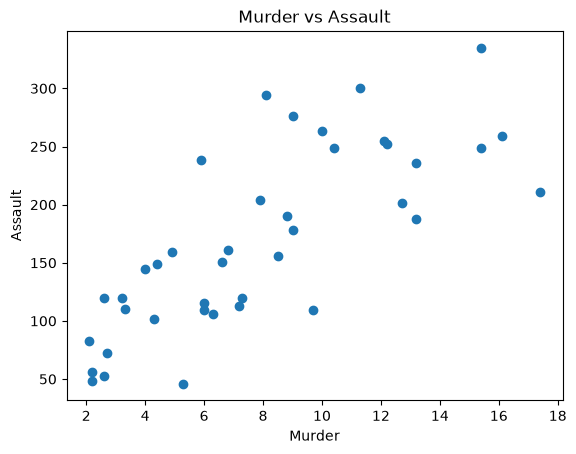

In [17]:
plt.scatter(arrests["Murder"], arrests["Assault"])
plt.xlabel("Murder")
plt.ylabel("Assault")
plt.title("Murder vs Assault")
plt.show()

###1.3.1. 
positive relationship between murder and assault rates. 

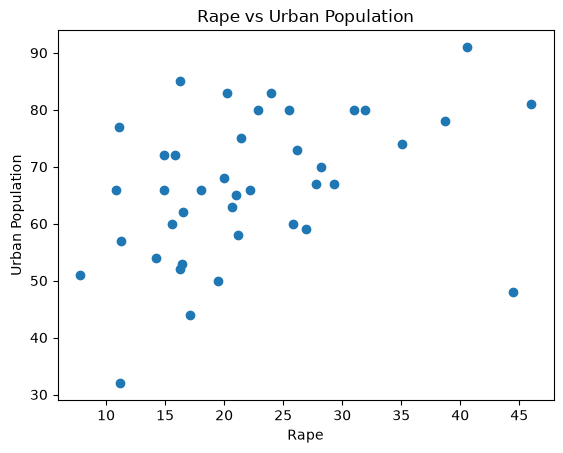

In [19]:
plt.scatter(arrests["Rape"], arrests["UrbanPop"])
plt.xlabel("Rape")
plt.ylabel("Urban Population")
plt.title("Rape vs Urban Population")
plt.show()

In [20]:
arrests.sort_values("Rape", ascending=False).head()

,State,Murder,Assault,UrbanPop,Rape,lon,lat
27,Nevada,12.2,252,81,46.0,-117.034132,39.656972
1,Alaska,10.0,263,48,44.5,-168.187471,53.330810
4,California,9.0,276,91,40.6,-120.386476,34.034180
5,Colorado,7.9,204,78,38.7,-105.837605,40.112391
21,Michigan,12.1,255,74,35.1,-85.553712,45.662505


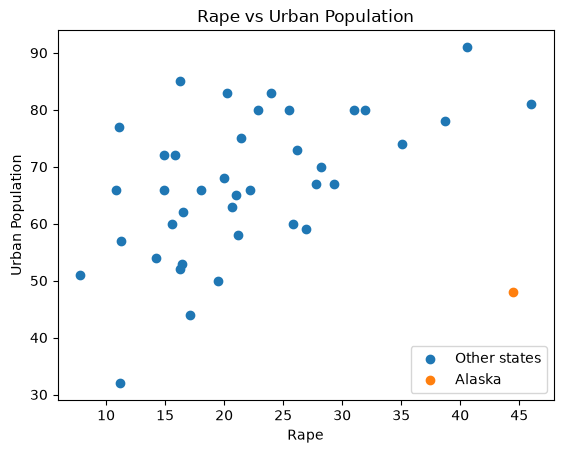

In [21]:
outlier = arrests["State"] == "Alaska"

plt.scatter(
    arrests.loc[~outlier, "Rape"],
    arrests.loc[~outlier, "UrbanPop"],
    label="Other states"
)

plt.scatter(
    arrests.loc[outlier, "Rape"],
    arrests.loc[outlier, "UrbanPop"],
    label="Alaska"
)

plt.xlabel("Rape")
plt.ylabel("Urban Population")
plt.title("Rape vs Urban Population")
plt.legend()
plt.show()

Alaska appears to be an outlier

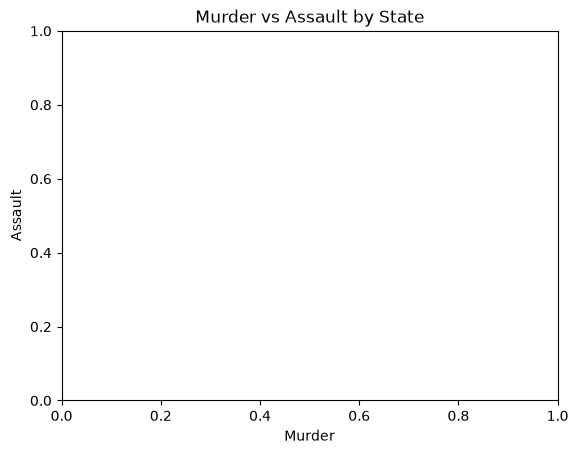

In [22]:
for _, row in arrests.iterrows():
    plt.annotate(
        row["State"],
        (row["Murder"], row["Assault"]),
        fontsize=8
    )

plt.xlabel("Murder")
plt.ylabel("Assault")
plt.title("Murder vs Assault by State")
plt.show()

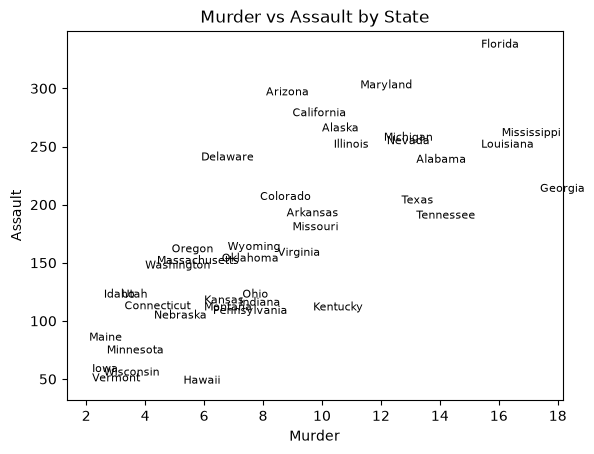

In [23]:
plt.scatter(arrests["Murder"], arrests["Assault"], alpha=0)

for _, row in arrests.iterrows():
    plt.annotate(
        row["State"],
        (row["Murder"], row["Assault"]),
        fontsize=8
    )

plt.xlabel("Murder")
plt.ylabel("Assault")
plt.title("Murder vs Assault by State")
plt.show()

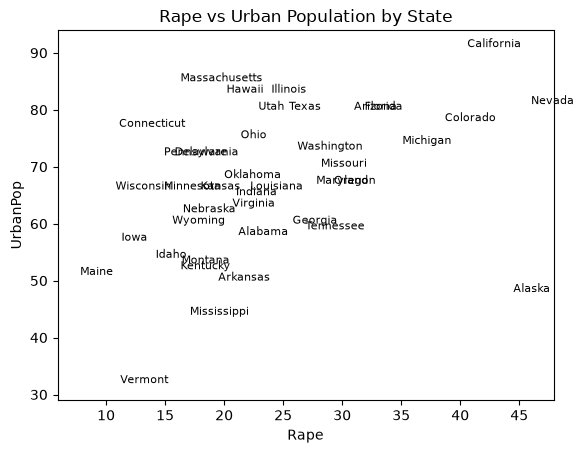

In [25]:
plt.scatter(arrests["Rape"], arrests["UrbanPop"], alpha=0)

for _, row in arrests.iterrows():
    plt.annotate(
        row["State"],
        (row["Rape"], row["UrbanPop"]),
        fontsize=8
    )

plt.xlabel("Rape")
plt.ylabel("UrbanPop")
plt.title("Rape vs Urban Population by State")
plt.show()

In [26]:
reg_data = arrests.drop(columns=["Murder", "Assault"])

In [27]:
reg_data.head()

,State,UrbanPop,Rape,lon,lat
0,Alabama,58,21.2,-86.592392,34.735676
1,Alaska,48,44.5,-168.187471,53.330810
2,Arizona,80,31.0,-111.615136,36.246377
3,Arkansas,50,19.5,-92.240455,36.374502
4,California,91,40.6,-120.386476,34.034180


In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
X = reg_data[["Rape"]]
y = reg_data["UrbanPop"]

In [30]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.56]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Rape']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,54.11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [31]:
predicted = model.predict(X)

In [32]:
residuals = y - predicted

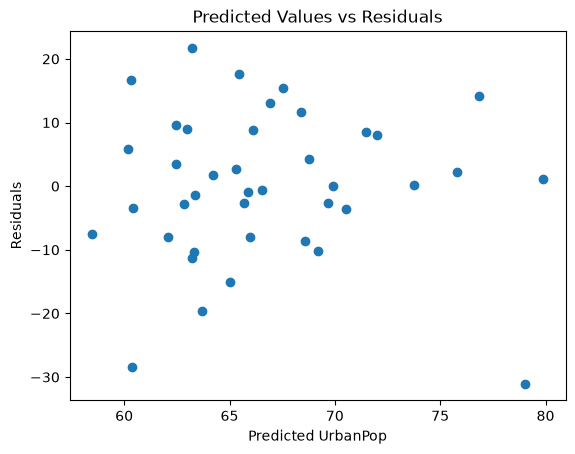

In [33]:
plt.scatter(predicted, residuals)
plt.xlabel("Predicted UrbanPop")
plt.ylabel("Residuals")
plt.title("Predicted Values vs Residuals")
plt.show()

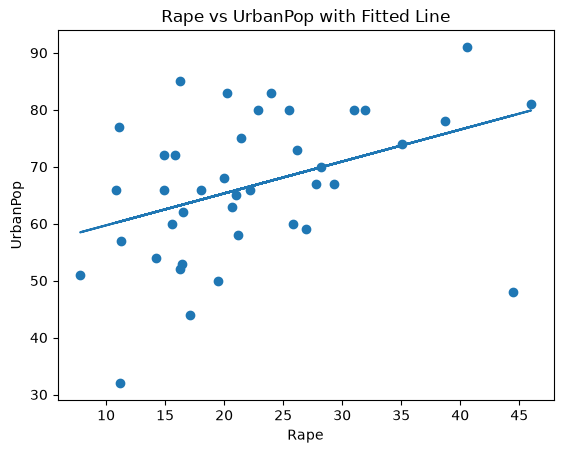

In [34]:
plt.scatter(reg_data["Rape"], reg_data["UrbanPop"])

plt.plot(reg_data["Rape"],predicted)

plt.xlabel("Rape")
plt.ylabel("UrbanPop")
plt.title("Rape vs UrbanPop with Fitted Line")
plt.show()

In [35]:
reg_no_outlier = reg_data[reg_data["State"] != "Alaska"]
X2 = reg_no_outlier[["Rape"]]
y2 = reg_no_outlier["UrbanPop"]

In [36]:
model2 = LinearRegression()
model2.fit(X2, y2)
predicted2 = model2.predict(X2)

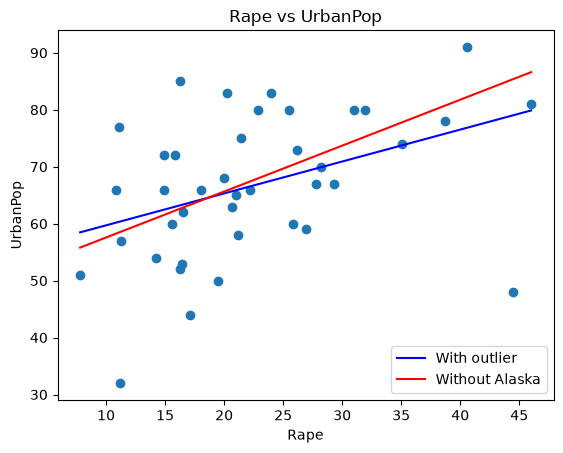

In [37]:
plt.scatter(reg_data["Rape"], reg_data["UrbanPop"])

order1 = reg_data["Rape"].argsort()
plt.plot(
    reg_data["Rape"].iloc[order1],
    predicted[order1],
    color="blue",
    label="With outlier"
)

order2 = reg_no_outlier["Rape"].argsort()
plt.plot(
    reg_no_outlier["Rape"].iloc[order2],
    predicted2[order2],
    color="red",
    label="Without Alaska"
)

plt.xlabel("Rape")
plt.ylabel("UrbanPop")
plt.title("Rape vs UrbanPop")
plt.legend()
plt.show()